In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [5]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import butter, sosfiltfilt

# ================================
# GENERALIZED FUNCTIONS
# ================================

def design_butterworth_filter(fs, period_hours=None, period_minutes=None, period_seconds=None, order=4):
    """
    Design a Butterworth low-pass filter based on the PERIOD you want to preserve.
    
    Parameters:
    -----------
    fs : float
        Sampling frequency in Hz
    period_hours : float, optional
        Minimum period to preserve in hours (e.g., 2 means keep variations slower than 2 hours)
    period_minutes : float, optional
        Minimum period to preserve in minutes
    period_seconds : float, optional
        Minimum period to preserve in seconds
    order : int
        Filter order (default: 4)
    
    Returns:
    --------
    sos : array
        Second-order sections representation of the filter
    cutoff : float
        The actual cutoff frequency used (in Hz)
    period_used : float
        The period used (in seconds)
    
    Note: Provide only ONE of period_hours, period_minutes, or period_seconds
    """
    # Convert period to seconds
    if period_hours is not None:
        period_sec = period_hours * 3600
    elif period_minutes is not None:
        period_sec = period_minutes * 60
    elif period_seconds is not None:
        period_sec = period_seconds
    else:
        raise ValueError("Must specify one of: period_hours, period_minutes, or period_seconds")
    
    # Convert period to frequency
    # Using 2x safety factor: cutoff at half the period
    cutoff = 1.0 / (period_sec * 2)
    
    # Safety check against Nyquist
    nyquist = fs / 2
    if cutoff >= nyquist:
        print(f"WARNING: Requested cutoff {cutoff:.6f} Hz >= Nyquist {nyquist:.6f} Hz")
        cutoff = nyquist * 0.8
        actual_period = 1.0 / cutoff
        print(f"Adjusting to {cutoff:.6f} Hz (period: {actual_period/60:.1f} minutes)")
    
    # Design filter
    sos = butter(N=order, Wn=cutoff, btype="low", fs=fs, output="sos")
    
    print(f"\nFilter designed:")
    print(f"  Preserves variations SLOWER than {period_sec/60:.1f} minutes")
    print(f"  Removes variations FASTER than {period_sec/60:.1f} minutes")
    print(f"  Cutoff frequency: {cutoff:.6f} Hz")
    
    return sos, cutoff, period_sec


def apply_butterworth_filter(df, column_name, sos, output_column_name=None):
    """
    Apply Butterworth filter to a specified column with NaN handling.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    column_name : str
        Name of column to filter (e.g., "MCP_WQ_TDS", "MCP_WQ_EC")
    sos : array
        Second-order sections representation of the IIR filter
    output_column_name : str, optional
        Name for filtered output column. If None, uses "{column_name}_filtered"
    
    Returns:
    --------
    pd.DataFrame
        Dataframe with added filtered column
    """
    if output_column_name is None:
        output_column_name = f"{column_name}_filtered"
    
    # Extract data
    data = df[column_name].astype(float).values
    
    # Check for NaNs
    if np.any(np.isnan(data)):
        nan_count = np.sum(np.isnan(data))
        print(f"WARNING: Found {nan_count} NaN values in {column_name}. Interpolating...")
        data = pd.Series(data).interpolate(method='linear').values
    
    # Apply filter
    data_filtered = sosfiltfilt(sos, data)
    df[output_column_name] = data_filtered
    
    return df


def plot_filtered_data(df, column_name, filtered_column_name=None, 
                       title=None, ylabel=None, 
                       figsize=(14, 6), hour_interval=6):
    """
    Plot filtered data only.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe containing DateTime and data columns
    column_name : str
        Name of raw data column (e.g., "MCP_WQ_TDS", "MCP_WQ_EC")
    filtered_column_name : str, optional
        Name of filtered data column. If None, uses "{column_name}_filtered"
    title : str, optional
        Plot title. If None, auto-generated
    ylabel : str, optional
        Y-axis label. If None, uses column_name
    figsize : tuple
        Figure size (width, height)
    hour_interval : int
        Hour interval for x-axis ticks
    """
    if filtered_column_name is None:
        filtered_column_name = f"{column_name}_filtered"
    
    # Auto-generate labels if not provided
    if title is None:
        param_name = column_name.replace("MCP_WQ_", "")
        param_full = {
            "TDS": "Total Dissolved Solids",
            "EC": "Electrical Conductivity"
        }.get(param_name, param_name)
        title = f"{param_full} vs Time (Butterworth Filtered)"
    
    if ylabel is None:
        ylabel = column_name
    
    # Create plot
    plt.figure(figsize=figsize)
    
    plt.plot(df["DateTime"], df[filtered_column_name],
             label=f"Filtered {column_name.replace('MCP_WQ_', '')}", 
             linewidth=2, color='red')
    
    plt.title(title)
    plt.xlabel("DateTime")
    plt.ylabel(ylabel)
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=hour_interval))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nFiltering complete for {column_name}:")
    print(f"  Raw: {df[column_name].min():.2f} to {df[column_name].max():.2f}")
    print(f"  Filtered: {df[filtered_column_name].min():.2f} to {df[filtered_column_name].max():.2f}")


def process_and_plot(df, column_name, sos, 
                     filtered_column_name=None,
                     title=None, ylabel=None,
                     figsize=(14, 6), hour_interval=6):
    """
    Convenience function: apply filter and plot in one call.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    column_name : str
        Name of column to filter (e.g., "MCP_WQ_TDS", "MCP_WQ_EC")
    sos : array
        Second-order sections representation of the IIR filter
    filtered_column_name : str, optional
        Name for filtered output column
    title : str, optional
        Plot title
    ylabel : str, optional
        Y-axis label
    figsize : tuple
        Figure size
    hour_interval : int
        Hour interval for x-axis ticks
    
    Returns:
    --------
    pd.DataFrame
        Dataframe with added filtered column
    """
    df = apply_butterworth_filter(df, column_name, sos, filtered_column_name)
    plot_filtered_data(df, column_name, filtered_column_name, 
                      title, ylabel, figsize, hour_interval)
    return df


def plot_overlay(df, column_names, filtered_column_names=None,
                 title=None, ylabel=None, 
                 figsize=(14, 6), hour_interval=6,
                 colors=None, labels=None):
    """
    Plot multiple filtered data series overlaid on the same graph.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe containing DateTime and data columns
    column_names : list of str
        List of column names to overlay (e.g., ["MCP_WQ_TDS", "MCP_WQ_EC"])
    filtered_column_names : list of str, optional
        List of filtered column names. If None, uses "{column_name}_filtered" for each
    title : str, optional
        Plot title. If None, auto-generated
    ylabel : str, optional
        Y-axis label. If None, auto-generated
    figsize : tuple
        Figure size (width, height)
    hour_interval : int
        Hour interval for x-axis ticks
    colors : list of str, optional
        List of colors for each line. If None, uses default color cycle
    labels : list of str, optional
        List of labels for legend. If None, auto-generated from column names
    """
    if filtered_column_names is None:
        filtered_column_names = [f"{col}_filtered" for col in column_names]
    
    if colors is None:
        colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    
    if labels is None:
        labels = [col.replace("MCP_WQ_", "") for col in column_names]
    
    # Auto-generate title if not provided
    if title is None:
        title = "Water Quality Parameters vs Time (Butterworth Filtered)"
    
    if ylabel is None:
        ylabel = "Filtered Values"
    
    # Create plot
    plt.figure(figsize=figsize)
    
    for i, (col, filt_col, color, label) in enumerate(zip(column_names, filtered_column_names, colors, labels)):
        plt.plot(df["DateTime"], df[filt_col],
                 label=f"Filtered {label}", 
                 linewidth=2, color=color)
    
    plt.title(title)
    plt.xlabel("DateTime")
    plt.ylabel(ylabel)
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=hour_interval))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics for all columns
    print(f"\nOverlay statistics:")
    for col, filt_col, label in zip(column_names, filtered_column_names, labels):
        print(f"  {label}:")
        print(f"    Raw: {df[col].min():.2f} to {df[col].max():.2f}")
        print(f"    Filtered: {df[filt_col].min():.2f} to {df[filt_col].max():.2f}")



Files found:
 - C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-02-05.csv
Loading C:\Users\Dindo\Documents\aqpx\AQPX_data_log_2026-02-05.csv (date: 2026-02-05)

Stitched dataframe preview:
         Date      Time  StatusCode  MCP_WQ_DO  MCP_WQ_EC  MCP_WQ_PH  \
0  2026/02/05  00:00:50           0       67.0      203.0      460.0   
1  2026/02/05  00:00:55           0       63.0      199.0      461.0   
2  2026/02/05  00:01:00           0       63.0      202.0      461.0   
3  2026/02/05  00:01:05           0       54.0      210.0      460.0   
4  2026/02/05  00:01:10           0       62.0      209.0      461.0   

   MCP_WQ_TEMP  MCP_WQ_TURB  MCP_WQ_TDS  MCP_WQ_RSV1  MCP_WQ_RSV2  ADS_NO3_mA  \
0        236.0         22.0       218.0          9.0         11.0         0.0   
1        236.0         19.0       216.0          4.0          5.0         0.0   
2        236.0          9.0       220.0          2.0          2.0         0.0   
3        237.0          0.0       218.0          0.0 

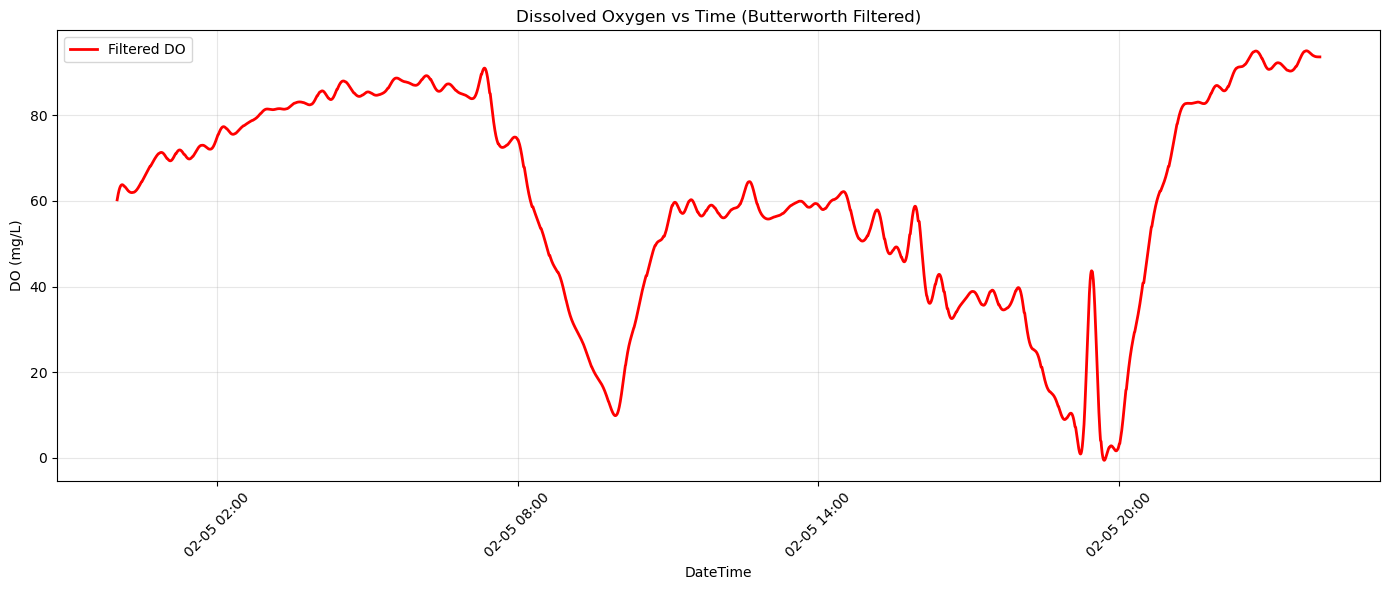


Filtering complete for MCP_WQ_DO:
  Raw: 0.00 to 304.00
  Filtered: -0.54 to 95.02


In [6]:
# ================================
# MAIN PROCESSING CODE
# ================================

# -----------------------------
# 1. FOLDER WITH YOUR CSV FILES
# -----------------------------
folder = r"C:\Users\Dindo\Documents\aqpx"
csv_files = glob.glob(f"{folder}/*.csv")
print("Files found:")
for f in csv_files:
    print(" -", f)

frames = []

# -----------------------------
# 2. PROCESS EACH CSV
# -----------------------------
for file in csv_files:
    match = re.search(r"(\d{4}-\d{2}-\d{2})", file)
    if match:
        date_str = match.group(1)
    else:
        raise ValueError(f"ERROR: No date found in filename: {file}")
    
    print(f"Loading {file} (date: {date_str})")
    df = pd.read_csv(file)
    df["Time"] = df["Time"].astype(str).str.strip()
    df["DateTime"] = pd.to_datetime(
        date_str + " " + df["Time"],
        errors="coerce"
    )
    frames.append(df)

# -----------------------------
# 3. STITCH ALL CSVs TOGETHER
# -----------------------------
full_df = pd.concat(frames, ignore_index=True)
full_df = full_df.sort_values("DateTime").reset_index(drop=True)

print("\nStitched dataframe preview:")
print(full_df.head())
print(full_df.tail())

# --------------------------------
# 4. COMPUTE SAMPLING FREQUENCY (fs)
# --------------------------------
dt_seconds = full_df["DateTime"].diff().dt.total_seconds().median()
fs = 1.0 / dt_seconds
print(f"\nEstimated sampling frequency: {fs:.6f} Hz "
      f"(Δt ≈ {dt_seconds:.2f} s)")

# ================================
# 5. DESIGN FILTER USING PERIODS
# ================================
# Example: Keep variations that take longer than 5 minutes to happen
sos, cutoff, period = design_butterworth_filter(fs, period_minutes=10, order=4)

# ================================
# 6. APPLY FILTER AND PLOT - DO
# ================================
full_df = process_and_plot(
    df=full_df,
    column_name="MCP_WQ_DO",
    sos=sos,
    title="Dissolved Oxygen vs Time (Butterworth Filtered)",
    ylabel="DO (mg/L)"
)

# ================================
# OPTIONAL: Try different filters
# ================================
# For aggressive smoothing (only hourly trends):
# sos_hourly, _, _ = design_butterworth_filter(fs, period_hours=1)
# full_df = process_and_plot(full_df, "MCP_WQ_DO", sos_hourly)

# For fine detail (30-second variations):
# sos_fine, _, _ = design_butterworth_filter(fs, period_seconds=30)
# full_df = process_and_plot(full_df, "MCP_WQ_DO", sos_fine)